In [24]:
import os.path
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [25]:
patient = pd.read_csv(os.path.join("data", "working_data", "week_5_data.csv")) 
air_pollution = pd.read_csv(os.path.join("data", "week_6", "cri_air_pollution.csv"))

In [26]:
patient.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,CURRENT_AGE,TOTAL_CONDITIONS,TOTAL_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,EMERGENCY_ENCOUNTER,URGENT_CARE_ENCOUNTER,ASTHMA_FU_ENCOUNTER
0,2e88d207-95b7-2ea8-ea61-b9f843bdfa91,2013-12-28,NaN,999-39-2671,NaN,NaN,NaN,Lucio648,Murazik203,NaN,NaN,NaN,white,nonhispanic,M,Quincy Massachusetts US,141 Olson Forge Suite 46,Oxford,Massachusetts,Worcester County,25027.0,1540,42.095155,-71.904253,4657.98,23106.82,10359,10.0,8,41,4,10,1.0,3.0,3.0
1,14012fd6-f062-1317-93aa-12aa96fd5f70,2015-01-17,NaN,999-79-6351,NaN,NaN,NaN,Freddie621,Murphy561,NaN,NaN,NaN,white,nonhispanic,F,Boston Massachusetts US,511 Schulist Highlands Suite 17,Petersham,Massachusetts,Worcester County,25027.0,1366,42.440328,-72.229864,32594.83,1207.52,792644,9.0,5,53,7,11,4.0,4.0,4.0
2,b43d2265-faaa-2f31-063e-0c7853c38d42,2014-10-22,NaN,999-48-1809,NaN,NaN,NaN,Antwan357,Bashirian201,NaN,NaN,NaN,white,nonhispanic,M,Wareham Center Massachusetts US,898 Terry Annex Unit 38,East Bridgewater,Massachusetts,Plymouth County,NaN,0,42.041716,-70.972879,11199.66,4704.96,62018,10.0,2,29,6,3,NaN,NaN,5.0
3,0fb829c8-debb-2e40-4597-675402fae580,2018-07-17,NaN,999-41-5688,NaN,NaN,NaN,Franklyn361,Welch179,NaN,NaN,NaN,white,nonhispanic,M,Cambridge Massachusetts US,665 Strosin Path Suite 83,Milton,Massachusetts,Norfolk County,25021.0,2186,42.217423,-71.073398,22108.33,1733.48,151475,6.0,6,30,1,8,NaN,2.0,NaN
4,ee03f050-bb11-28f0-715f-1e49a129cdf8,2014-03-21,NaN,999-18-4381,NaN,NaN,NaN,Luise714,Ziemann98,NaN,NaN,NaN,white,nonhispanic,F,Revere Massachusetts US,966 Zieme Forge Unit 49,Harwich Center,Massachusetts,Barnstable County,NaN,0,41.643285,-70.060511,2590.00,24978.31,16226,10.0,4,41,3,7,1.0,5.0,2.0


In [27]:
# 1.1	Import the air quality dataset and familiarize yourself with this dataset. Print the number of counties for which the data is available.

display(air_pollution.head())
print(air_pollution["County"].value_counts())

,County,Year,Measurement_avg pm25
0,Abington,2017,10.730195
1,Abington,2018,9.430195
2,Abington,2019,8.730195
3,Abington,2020,8.230195
4,Abington,2021,8.730195


County
Abington       8
Acton          8
Acushnet       8
Adams          8
Agawam         8
              ..
Woburn         8
Worcester      8
Worthington    8
Wrentham       8
Yarmouth       8
Name: count, Length: 351, dtype: int64


In [28]:
# 1.2	Transform the longitudinal air quality dataset into a format that can be merged with cross-sectional tables. 

air_pollution_wide = air_pollution.pivot_table(
    index="County",
    columns="Year",
    values="Measurement_avg pm25",
    aggfunc="mean"
).reset_index()

air_pollution_wide.columns = (
    ["County"] + [f"pm25_{int(y)}" for y in air_pollution_wide.columns[1:]]
)
air_pollution_wide.rename(columns={"County": "COUNTY"}, inplace=True)

In [29]:
air_pollution_wide.head()

,COUNTY,pm25_2017,pm25_2018,pm25_2019,pm25_2020,pm25_2021,pm25_2022,pm25_2023,pm25_2024
0,Abington,10.730195,9.430195,8.730195,8.230195,8.730195,7.930195,7.730195,6.530195
1,Acton,11.000000,10.000000,9.000000,8.500000,9.100000,8.600000,8.400000,7.800000
2,Acushnet,8.431250,7.831250,6.931250,6.531250,7.131250,6.231250,6.231250,5.331250
3,Adams,10.021875,9.821875,8.921875,8.421875,8.821875,8.321875,8.321875,8.621875
4,Agawam,11.367045,10.567045,9.267045,8.667045,10.067045,8.767045,8.767045,8.267045


In [30]:
merged = pd.merge(patient, air_pollution_wide, how="left", left_on="CITY",              
right_on="COUNTY")

# Drop the duplicate and rename the keeper
merged = merged.drop(columns=["COUNTY_x", "COUNTY_y"])

merged.head()   

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,CURRENT_AGE,TOTAL_CONDITIONS,TOTAL_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,EMERGENCY_ENCOUNTER,URGENT_CARE_ENCOUNTER,ASTHMA_FU_ENCOUNTER,pm25_2017,pm25_2018,pm25_2019,pm25_2020,pm25_2021,pm25_2022,pm25_2023,pm25_2024
0,2e88d207-95b7-2ea8-ea61-b9f843bdfa91,2013-12-28,NaN,999-39-2671,NaN,NaN,NaN,Lucio648,Murazik203,NaN,NaN,NaN,white,nonhispanic,M,Quincy Massachusetts US,141 Olson Forge Suite 46,Oxford,Massachusetts,25027.0,1540,42.095155,-71.904253,4657.98,23106.82,10359,10.0,8,41,4,10,1.0,3.0,3.0,9.705000,8.905000,7.905000,7.305000,8.205000,7.405000,7.505000,6.505000
1,14012fd6-f062-1317-93aa-12aa96fd5f70,2015-01-17,NaN,999-79-6351,NaN,NaN,NaN,Freddie621,Murphy561,NaN,NaN,NaN,white,nonhispanic,F,Boston Massachusetts US,511 Schulist Highlands Suite 17,Petersham,Massachusetts,25027.0,1366,42.440328,-72.229864,32594.83,1207.52,792644,9.0,5,53,7,11,4.0,4.0,4.0,10.150000,9.750000,8.850000,8.250000,8.850000,8.350000,8.350000,8.050000
2,b43d2265-faaa-2f31-063e-0c7853c38d42,2014-10-22,NaN,999-48-1809,NaN,NaN,NaN,Antwan357,Bashirian201,NaN,NaN,NaN,white,nonhispanic,M,Wareham Center Massachusetts US,898 Terry Annex Unit 38,East Bridgewater,Massachusetts,NaN,0,42.041716,-70.972879,11199.66,4704.96,62018,10.0,2,29,6,3,NaN,NaN,5.0,10.970000,9.770000,8.970000,8.470000,9.070000,8.370000,8.070000,7.070000
3,0fb829c8-debb-2e40-4597-675402fae580,2018-07-17,NaN,999-41-5688,NaN,NaN,NaN,Franklyn361,Welch179,NaN,NaN,NaN,white,nonhispanic,M,Cambridge Massachusetts US,665 Strosin Path Suite 83,Milton,Massachusetts,25021.0,2186,42.217423,-71.073398,22108.33,1733.48,151475,6.0,6,30,1,8,NaN,2.0,NaN,10.895455,9.595455,8.795455,8.395455,8.895455,7.995455,7.695455,6.295455
4,ee03f050-bb11-28f0-715f-1e49a129cdf8,2014-03-21,NaN,999-18-4381,NaN,NaN,NaN,Luise714,Ziemann98,NaN,NaN,NaN,white,nonhispanic,F,Revere Massachusetts US,966 Zieme Forge Unit 49,Harwich Center,Massachusetts,NaN,0,41.643285,-70.060511,2590.00,24978.31,16226,10.0,4,41,3,7,1.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# 2.1  exploring the air quality data by using descriptive statistics and data visualization.

# Compute a single mean PM2.5 for multiple years
pm25_cols = [c for c in merged.columns if c.startswith('pm25_')]
merged['pm25_mean'] = merged[pm25_cols].mean(axis=1)

# Descriptive statistics for AQ and asthma severity variables
severity_cols = [
    'pm25_mean',
    'EMERGENCY_ENCOUNTER',
    'ASTHMA_REASON_ENCOUNTER',
    'SYMPTOM_ENCOUNTER',
    'ACTIVE_ALLERGY_COUNT',
    'INCOME',
]
severity_cols = [c for c in severity_cols if c in merged.columns]  # keep only present cols

print('=== Descriptive statistics ===')
display(merged[severity_cols].describe().round(2))

print('\n=== Pearson correlations with pm25_mean ===')
print(merged[severity_cols].corr()['pm25_mean'].drop('pm25_mean').sort_values().round(3))


=== Descriptive statistics ===


,pm25_mean,EMERGENCY_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,INCOME
count,1598.00,1290.00,1668.00,1668.00,1668.00
mean,8.54,2.09,4.11,5.73,142330.34
std,0.83,2.45,2.13,2.22,215566.36
min,5.85,1.00,1.00,1.00,29.00
25%,8.03,1.00,2.00,4.00,26760.00
50%,8.57,2.00,4.00,5.00,68836.50
75%,9.18,2.00,5.00,7.00,136433.00
max,10.96,20.00,12.00,17.00,990714.00



=== Pearson correlations with pm25_mean ===
SYMPTOM_ENCOUNTER          0.007
EMERGENCY_ENCOUNTER        0.029
INCOME                     0.045
ASTHMA_REASON_ENCOUNTER    0.378
Name: pm25_mean, dtype: float64


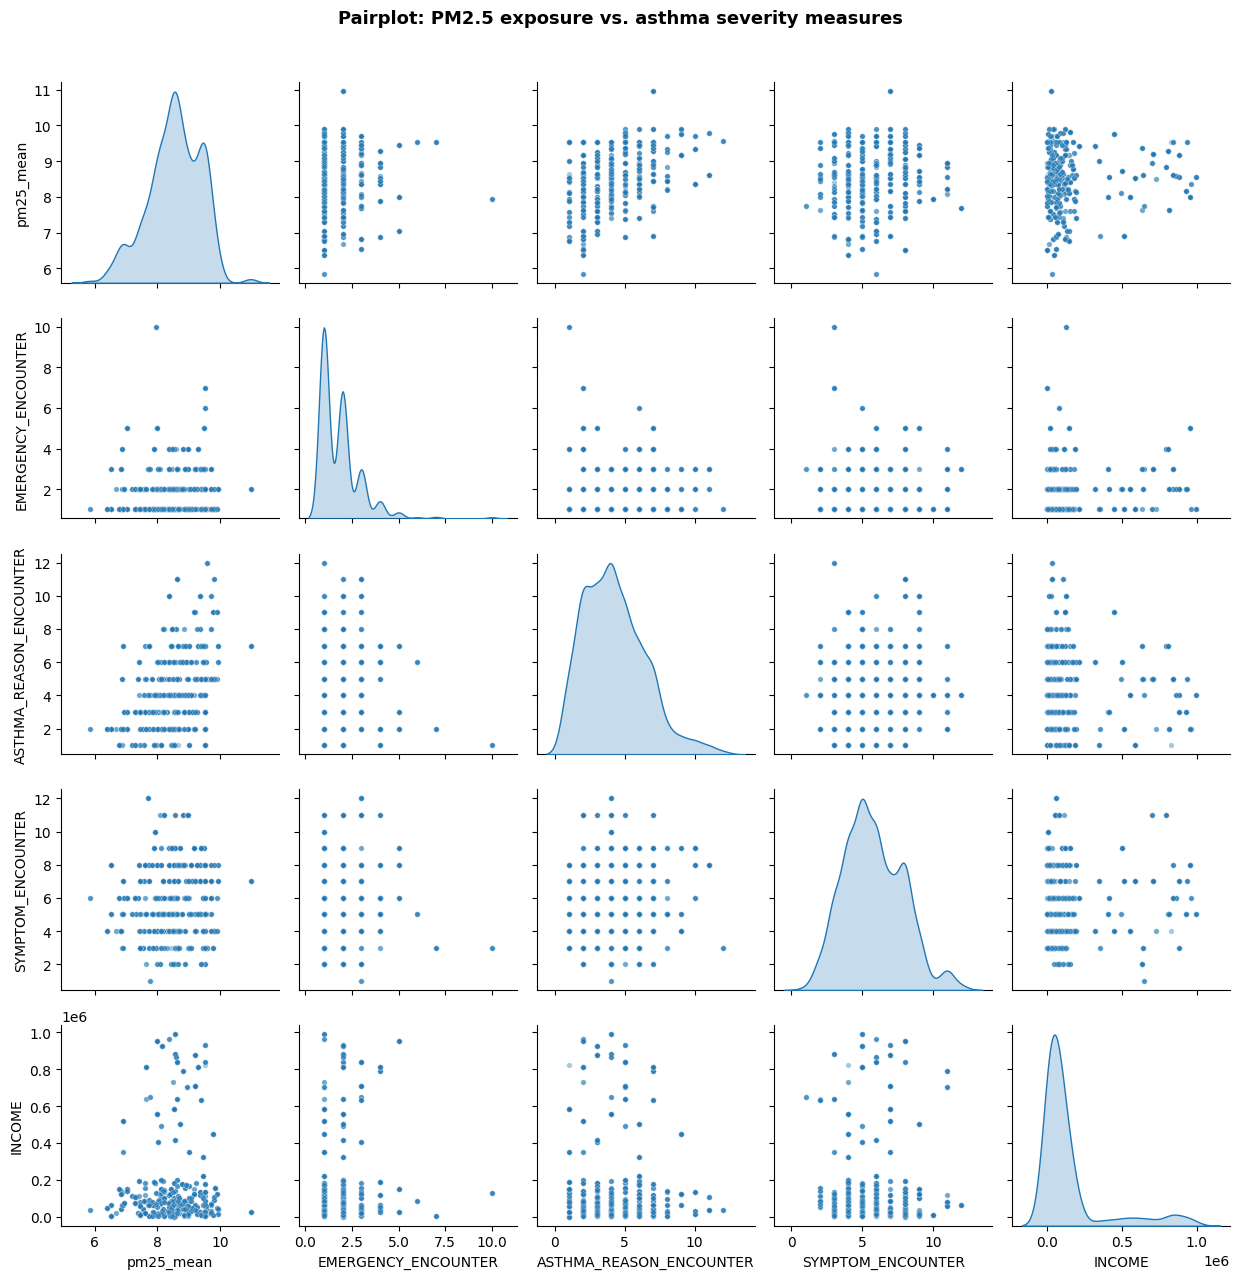

In [32]:
# Pairplot: visualising pairwise relationships between PM2.5 and asthma severity
import matplotlib.pyplot as plt

g = sns.pairplot(
    merged[severity_cols].dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
)
g.figure.suptitle('Pairplot: PM2.5 exposure vs. asthma severity measures',
                   y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
# 2.2  Create categories to explore the relationship between air pollution and asthma severity
#
#  ── Binary category: High vs Low PM2.5 (split at median) ─────────────────
pm25_median = merged['pm25_mean'].median()
merged['pm25_category'] = np.where(
    merged['pm25_mean'] > pm25_median, 'High PM2.5', 'Low PM2.5'
)

# ── Ordinal category: EPA-style PM2.5 quartile tiers ──────────────────────
merged['pm25_quartile'] = pd.qcut(
    merged['pm25_mean'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

print('Binary category distribution:')
print(merged['pm25_category'].value_counts().to_string())
print()
print('Quartile category distribution:')
print(merged['pm25_quartile'].value_counts().sort_index().to_string())

# Mean severity by binary category
asthma_severity_cols = [c for c in [
    'EMERGENCY_ENCOUNTER', 'ASTHMA_REASON_ENCOUNTER', 'SYMPTOM_ENCOUNTER', 'ACTIVE_ALLERGY_COUNT'
] if c in merged.columns]

print('\nMean asthma severity by PM2.5 category:')
display(merged.groupby('pm25_category')[asthma_severity_cols].mean().round(3))


Binary category distribution:
pm25_category
Low PM2.5     876
High PM2.5    792

Quartile category distribution:
pm25_quartile
Q1 (Lowest)     407
Q2              399
Q3              409
Q4 (Highest)    383

Mean asthma severity by PM2.5 category:


,EMERGENCY_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER
pm25_category,,,
High PM2.5,1.876,4.827,5.801
Low PM2.5,2.272,3.458,5.666


/tmp/ipykernel_9795/3656920604.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9795/3656920604.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9795/3656920604.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


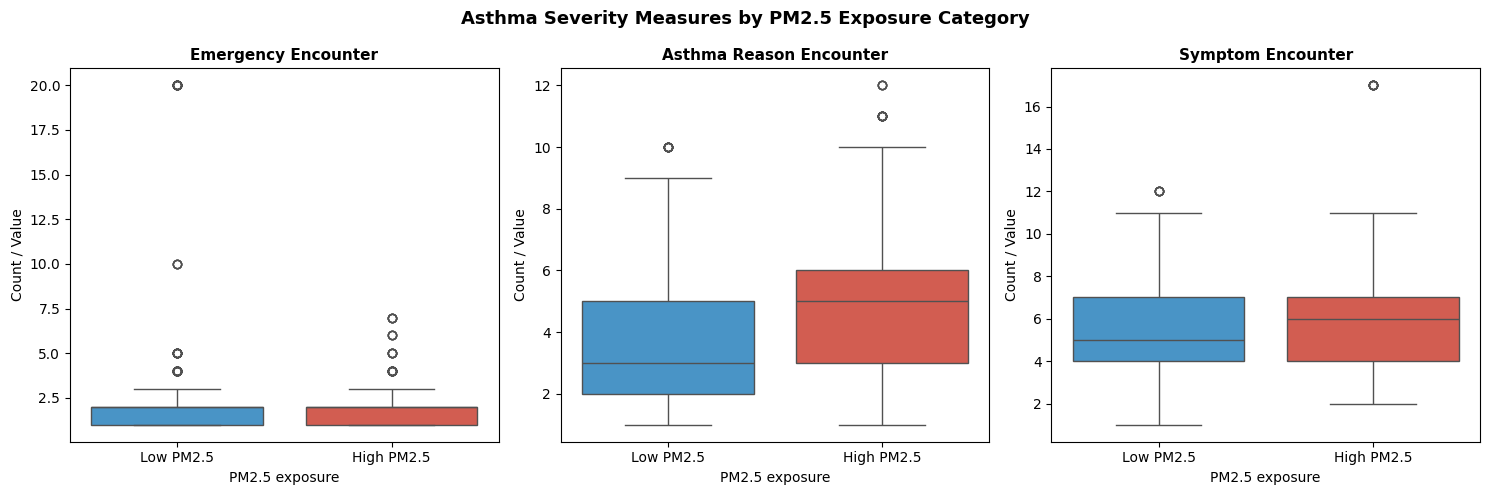

Saved: visualization_1_boxplots.png


In [34]:
# 2.3  Data visualizations: disease severity vs. air pollution

# ── Visualization 1: Boxplots — asthma severity by binary PM2.5 category ──
fig, axes = plt.subplots(1, len(asthma_severity_cols),
                         figsize=(5 * len(asthma_severity_cols), 5),
                         sharey=False)
if len(asthma_severity_cols) == 1:
    axes = [axes]

palette = {'High PM2.5': '#e74c3c', 'Low PM2.5': '#3498db'}

for ax, col in zip(axes, asthma_severity_cols):
    sns.boxplot(
        data=merged,
        x='pm25_category', y=col,
        palette=palette,
        order=['Low PM2.5', 'High PM2.5'],
        ax=ax
    )
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('PM2.5 exposure', fontsize=10)
    ax.set_ylabel('Count / Value', fontsize=10)

fig.suptitle('Asthma Severity Measures by PM2.5 Exposure Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visualization_1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualization_1_boxplots.png')


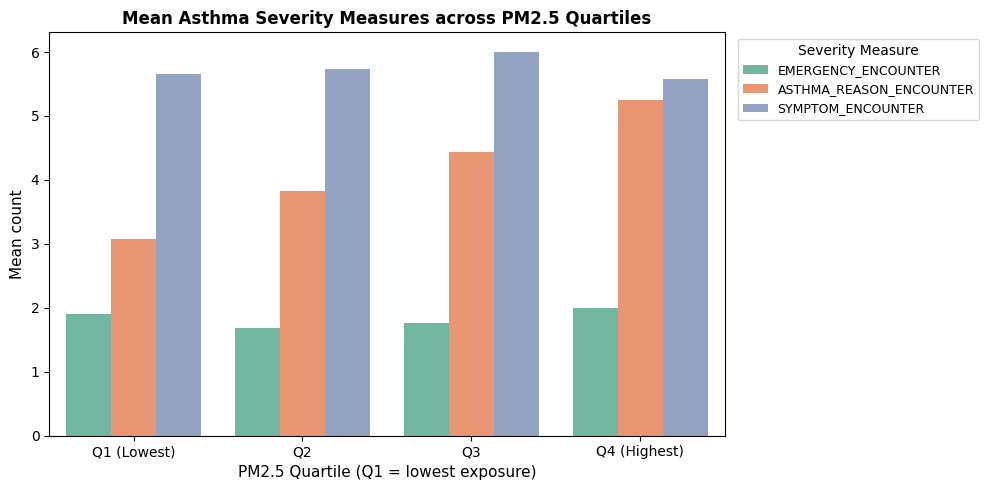

Saved: visualization_2_quartile_bars.png


In [35]:
# ── Visualization 2: Mean severity by PM2.5 quartile (grouped bar chart) ──
quartile_means = (
    merged.groupby('pm25_quartile', observed=True)[asthma_severity_cols]
    .mean()
    .reset_index()
)
quartile_melted = quartile_means.melt(
    id_vars='pm25_quartile', var_name='Severity Measure', value_name='Mean Value'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=quartile_melted,
    x='pm25_quartile', y='Mean Value',
    hue='Severity Measure',
    palette='Set2',
    ax=ax
)
ax.set_xlabel('PM2.5 Quartile (Q1 = lowest exposure)', fontsize=11)
ax.set_ylabel('Mean count', fontsize=11)
ax.set_title('Mean Asthma Severity Measures across PM2.5 Quartiles',
             fontsize=12, fontweight='bold')
ax.legend(title='Severity Measure', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('visualization_2_quartile_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualization_2_quartile_bars.png')


In [36]:
# 3.1  Export a single DataFrame with demographic, clinical, and air quality variables

# Columns to export:
#   - demographic  : whatever demographic cols exist in patient / merged
#   - clinical     : asthma severity measures
#   - air quality  : pm25 per year + pm25_mean + categories

demo_keywords   = ['AGE', 'GENDER', 'RACE', 'ETHNICITY', 'INCOME', 'CITY', 'STATE', 'ZIP',
                   'COUNTY', 'EDUCATION']
clinical_keywords = ['ENCOUNTER', 'ALLERGY', 'ASTHMA', 'SYMPTOM', 'MEDICATION',
                     'CONDITION', 'OBSERVATION']
aq_keywords     = ['pm25', 'PM25', 'pollution', 'POLLUTION']

def select_cols(df, keywords):
    return [c for c in df.columns
            if any(kw.lower() in c.lower() for kw in keywords)]

demo_cols_final     = select_cols(merged, demo_keywords)
clinical_cols_final = select_cols(merged, clinical_keywords)
aq_cols_final       = select_cols(merged, aq_keywords)

# Combine, de-duplicate, keep order
export_cols = list(dict.fromkeys(demo_cols_final + clinical_cols_final + aq_cols_final))

df_export = merged[export_cols].copy()

print(f'Export shape: {df_export.shape}')
print('Columns included:')
for c in df_export.columns:
    print(f'  {c}')

export_path = os.path.join('data', 'working_data', 'week_6_data.csv')
df_export.to_csv(export_path, index=False)
print(f'\nSaved to: {export_path}')
df_export.head()


Export shape: (1668, 27)
Columns included:
  RACE
  ETHNICITY
  GENDER
  CITY
  STATE
  ZIP
  HEALTHCARE_COVERAGE
  INCOME
  CURRENT_AGE
  TOTAL_CONDITIONS
  TOTAL_ENCOUNTER
  ASTHMA_REASON_ENCOUNTER
  SYMPTOM_ENCOUNTER
  EMERGENCY_ENCOUNTER
  URGENT_CARE_ENCOUNTER
  ASTHMA_FU_ENCOUNTER
  pm25_2017
  pm25_2018
  pm25_2019
  pm25_2020
  pm25_2021
  pm25_2022
  pm25_2023
  pm25_2024
  pm25_mean
  pm25_category
  pm25_quartile

Saved to: data/working_data/week_6_data.csv


,RACE,ETHNICITY,GENDER,CITY,STATE,ZIP,HEALTHCARE_COVERAGE,INCOME,CURRENT_AGE,TOTAL_CONDITIONS,TOTAL_ENCOUNTER,ASTHMA_REASON_ENCOUNTER,SYMPTOM_ENCOUNTER,EMERGENCY_ENCOUNTER,URGENT_CARE_ENCOUNTER,ASTHMA_FU_ENCOUNTER,pm25_2017,pm25_2018,pm25_2019,pm25_2020,pm25_2021,pm25_2022,pm25_2023,pm25_2024,pm25_mean,pm25_category,pm25_quartile
0,white,nonhispanic,M,Oxford,Massachusetts,1540,23106.82,10359,10.0,8,41,4,10,1.0,3.0,3.0,9.705000,8.905000,7.905000,7.305000,8.205000,7.405000,7.505000,6.505000,7.930000,Low PM2.5,Q1 (Lowest)
1,white,nonhispanic,F,Petersham,Massachusetts,1366,1207.52,792644,9.0,5,53,7,11,4.0,4.0,4.0,10.150000,9.750000,8.850000,8.250000,8.850000,8.350000,8.350000,8.050000,8.825000,High PM2.5,Q3
2,white,nonhispanic,M,East Bridgewater,Massachusetts,0,4704.96,62018,10.0,2,29,6,3,NaN,NaN,5.0,10.970000,9.770000,8.970000,8.470000,9.070000,8.370000,8.070000,7.070000,8.845000,High PM2.5,Q3
3,white,nonhispanic,M,Milton,Massachusetts,2186,1733.48,151475,6.0,6,30,1,8,NaN,2.0,NaN,10.895455,9.595455,8.795455,8.395455,8.895455,7.995455,7.695455,6.295455,8.570455,Low PM2.5,Q2
4,white,nonhispanic,F,Harwich Center,Massachusetts,0,24978.31,16226,10.0,4,41,3,7,1.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low PM2.5,NaN
